In [1]:
# 데이터 처리 & 시각화 라이브러리
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 분석 라이브러리
from sklearn.datasets import load_breast_cancer           # 유방암 진단 예제 데이터
from sklearn.model_selection import train_test_split      # 데이터 분할 라이브러리
from sklearn.preprocessing import StandardScaler          # 데이터 정규화
from sklearn.metrics import(                              # 모델 평가 매트릭
accuracy_score,
precision_score,
recall_score,
f1_score,
confusion_matrix,
roc_curve,
auc
)

from sklearn.linear_model import LogisticRegression       # 로지스틱리그레션 모델


# 데이터 로드

In [13]:
# 유방암 데이터셋 로드(이진 분류 문제)
data = load_breast_cancer()

# 입력 변수 (feature)
X = data.data

# 타겟변수 (target)
y = data.target

In [14]:
X

array([[1.799e+01, 1.038e+01, 1.228e+02, ..., 2.654e-01, 4.601e-01,
        1.189e-01],
       [2.057e+01, 1.777e+01, 1.329e+02, ..., 1.860e-01, 2.750e-01,
        8.902e-02],
       [1.969e+01, 2.125e+01, 1.300e+02, ..., 2.430e-01, 3.613e-01,
        8.758e-02],
       ...,
       [1.660e+01, 2.808e+01, 1.083e+02, ..., 1.418e-01, 2.218e-01,
        7.820e-02],
       [2.060e+01, 2.933e+01, 1.401e+02, ..., 2.650e-01, 4.087e-01,
        1.240e-01],
       [7.760e+00, 2.454e+01, 4.792e+01, ..., 0.000e+00, 2.871e-01,
        7.039e-02]], shape=(569, 30))

In [15]:
y

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0,
       0, 0, 1, 0, 1, 1, 1, 1, 1, 0, 0, 1, 0, 0, 1, 1, 1, 1, 0, 1, 0, 0,
       1, 1, 1, 1, 0, 1, 0, 0, 1, 0, 1, 0, 0, 1, 1, 1, 0, 0, 1, 0, 0, 0,
       1, 1, 1, 0, 1, 1, 0, 0, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 1, 1, 0, 1,
       1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 1, 0, 0, 1, 1, 1, 0, 0, 1, 0, 1, 0,
       0, 1, 0, 0, 1, 1, 0, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 0, 1, 1, 1, 1, 0, 0, 1, 0, 1, 1, 0, 0, 1, 1, 0, 0, 1, 1, 1,
       1, 0, 1, 1, 0, 0, 0, 1, 0, 1, 0, 1, 1, 1, 0, 1, 1, 0, 0, 1, 0, 0,
       0, 0, 1, 0, 0, 0, 1, 0, 1, 0, 1, 1, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0,
       1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 0, 1, 1, 0, 1, 1, 0, 0, 1, 0, 1, 1,
       1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 0, 1, 1, 0, 1, 0, 0, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 0,

# 데이터 분할

In [16]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,                             
    test_size = 0.2,       # 20% test data 설정, 학습 데이터는 80%    
    random_state = 42      # 결과 재현 기능
)

# 데이터 전처리 (정규화)

In [17]:
# StandardScaler 라이브러리로 정규활 생성 (평균 = 0, 표준편차=1)
scaler = StandardScaler()

# 학습 데이터로 scaler 학습 후 변환
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


# 모델 생성 및 학습

In [18]:
# logistic regression모델 생성
model = LogisticRegression()

# 모델 학습
model.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


# 예측 수행

In [19]:
# 클래스(y) 예측 (0 or 1) 
y_pred = model.predict(X_test)

# 확률 예측
y_prod = model.predict_proba(X_test)[:,1]

# 모델 성능 평가

In [20]:
# accuracy 계산
acc = accuracy_score(y_test, y_pred)

# precision 계산
precision = precision_score(y_test, y_pred)

# recall 계산
recall = recall_score(y_test, y_pred)

# F1-score 계산
f1 = f1_score(y_test, y_pred)

# 결과 출력
print("============= 모델 성능 =============")
print(f"Accuracy: {acc:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-Score: {f1:.4f}")


============= 모델 성능 =============
Accuracy: 0.9737
Precision: 0.9722
Recall: 0.9859
F1-Score: 0.9790


# Confusion Matrix 시각화

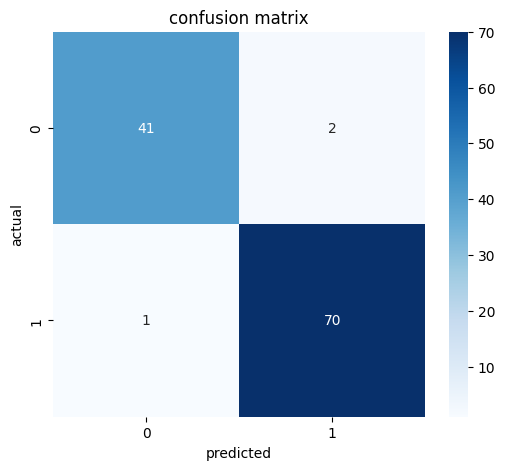

In [21]:
# confusion matrix 계산
cm = confusion_matrix(y_test, y_pred)

# heatmap으로 시각화
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.title('confusion matrix')
plt.xlabel('predicted')
plt.ylabel('actual')

plt.show()

# ROC Curve 시각화

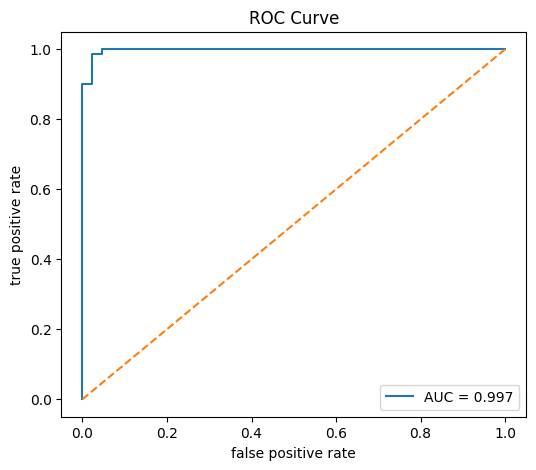

In [22]:
# FPR, TPR 계산
fpr, tpr, thresholds = roc_curve(y_test, y_prod)

# auc 계산
roc_auc = auc(fpr, tpr)

# 그래프 그리기
plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")

# 기준선
plt.plot([0,1], [0,1], linestyle='--')

plt.xlabel('false positive rate')
plt.ylabel('true positive rate')
plt.title('ROC Curve')

# 범례
plt.legend()

plt.show()

# 예측 결과 시각화

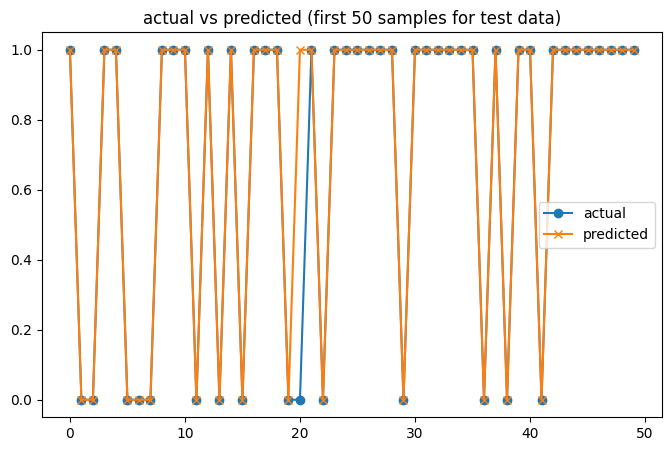

In [24]:
# 실제값 vs 예측값 비교
plt.figure(figsize=(8,5))

# 실제값
plt.plot(y_test[:50], label="actual", marker='o') 

# 예측값
plt.plot(y_pred[:50], label="predicted", marker='x')

plt.title('actual vs predicted (first 50 samples for test data)')
plt.legend()

plt.show()

         